# Phishing Website Detection
**AI4ALL Project - Group 13B**

## Project Description
This project uses machine learning to detect phishing websites.
We train models to classify websites as phishing or legitimate.
Dataset: 10,000 websites, 48 features.

## Team Members
- Aarushi Arora
- Purba Karmaker
- Varija Manglik
- Leah Wang
- Zheng Zhang
- Shreeshkumar Lillyprabhu
- Nardos Hailemariam

## Project Roadmap

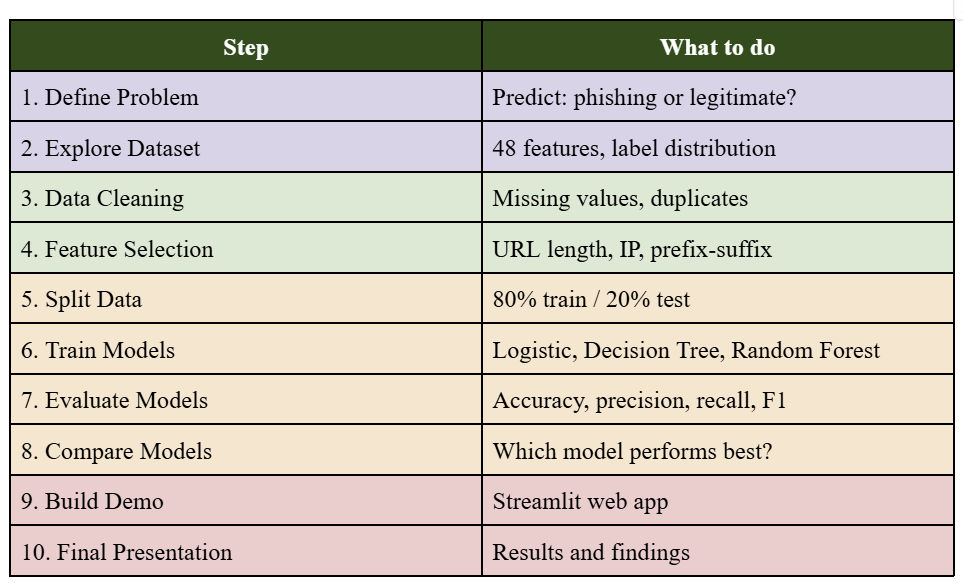


## Step 1: Define Problem

**Goal:** Predict if a website is phishing or legitimate.

**Input:** 48 website features (URL length, IP address, etc.)

**Output:** 
- 1 = Phishing (dangerous)
- 0 = Legitimate (safe)

**Models we will use:**
- Logistic Regression
- Decision Tree
- Random Forest

## Dataset Source
**Kaggle:** https://www.kaggle.com/datasets/shashwatwork/phishing-dataset-for-machine-learning

## How to Download
1. Go to the link above
2. Sign in to Kaggle
3. Click **Download** button
4. Unzip the file
5. Put `Phishing_Legitimate_full.csv` in your project folder

Dataset loaded! Shape: (10000, 50)

=== First 5 Rows ===


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1



=== Label Count ===


,count
CLASS_LABEL,
Phishing,5000
Legitimate,5000


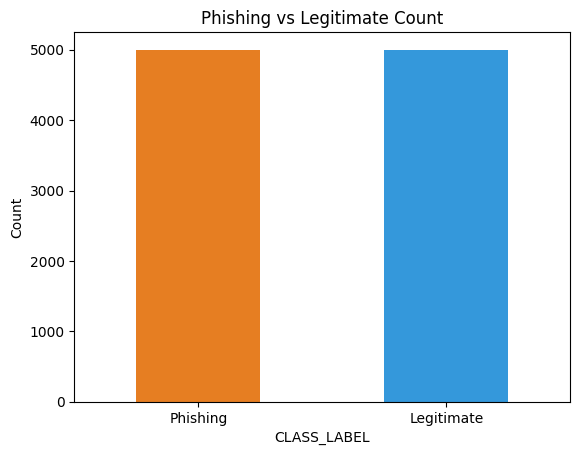


=== Missing Values ===


,Missing Count
id,0
NumDots,0
SubdomainLevel,0
PathLevel,0
UrlLength,0
NumDash,0
NumDashInHostname,0
AtSymbol,0
TildeSymbol,0
NumUnderscore,0



=== Stats Summary ===


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,2.45,0.59,3.30,70.26,1.82,0.14,0.00,0.01,0.32,...,0.34,0.03,0.03,0.96,0.02,0.35,0.79,0.17,0.31,0.5
std,2886.90,1.35,0.75,1.86,33.37,3.11,0.55,0.02,0.11,1.11,...,0.47,0.18,0.17,0.25,0.82,0.89,0.52,0.76,0.90,0.5
min,1.00,1.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,0.0
25%,2500.75,2.00,0.00,2.00,48.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,-1.00,-1.00,1.00,0.00,-1.00,0.0
50%,5000.50,2.00,1.00,3.00,62.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,1.00,0.5
75%,7500.25,3.00,1.00,4.00,84.00,2.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0
max,10000.00,21.00,14.00,18.00,253.00,55.00,9.00,1.00,1.00,18.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0


In [13]:
# Step 2: Explore Dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Phishing_Legitimate_full.csv')
print("Dataset loaded! Shape:", df.shape)

# Show first 5 rows to see what the data looks like
print("\n=== First 5 Rows ===")
display(df.head())

# Count how many phishing vs legitimate websites
# 1 = Phishing, 0 = Legitimate
print("\n=== Label Count ===")
label_df = df['CLASS_LABEL'].value_counts().rename({1: 'Phishing', 0: 'Legitimate'}).to_frame()
display(label_df.style.map(lambda x: 'background-color: #fce8e4' if x == 5000 else 'background-color: #e8f0e4'))

# Graph - easy to see 50/50 balance
df['CLASS_LABEL'].value_counts().rename({1: 'Phishing', 0: 'Legitimate'}).plot(
    kind='bar',
    color=['#e67e22', '#3498db'],
    title='Phishing vs Legitimate Count'
)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Check if any data is missing
# Green = no missing (good), Red = missing (bad)
print("\n=== Missing Values ===")
missing = df.isnull().sum().to_frame(name='Missing Count')
display(missing.style.map(lambda x: 'background-color: #e8f0e4' if x == 0 else 'background-color: #fce8e4'))

# Basic stats for each column (min, max, mean, etc.)
print("\n=== Stats Summary ===")
display(df.describe().round(2))

## Step 2 Summary

### What we found:
- Total data: **10,000 websites** (5,000 phishing + 5,000 legitimate)
- Total features: **48 columns**
- Missing values: **None** (data is clean)
- Labels are **perfectly balanced** (50% vs 50%)

### What this means:
- Data is ready for cleaning
- No need to fix missing values
- Balanced data = fair model training

### Next step:
-> Step 3: Data Cleaning

In [16]:
# Step 3: Data Cleaning
import pandas as pd

# Load the dataset
df = pd.read_csv('Phishing_Legitimate_full.csv')

# Check duplicates
print("=== Duplicates ===")
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Check missing values
print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "total missing values")

# Drop 'id' column (not useful for training)
df = df.drop(columns=['id'])
print("\nDropped 'id' column")
print("New shape:", df.shape)

# Final check
print("\n=== Clean Dataset Ready ===")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())

=== Duplicates ===
Duplicate rows: 0
After removing duplicates: (10000, 50)

=== Missing Values ===
0 total missing values

Dropped 'id' column
New shape: (10000, 49)

=== Clean Dataset Ready ===
Rows: 10000
Columns: 49


,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,3,1,5,72,0,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,3,1,3,144,0,0,0,0,2,0,...,0,0,0,1,-1,1,1,1,1,1
2,3,1,2,58,0,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,3,1,6,79,1,0,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,3,0,4,46,0,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


## Step 3 Summary

### What we did:
- Checked for duplicate rows and removed them
- Checked for missing values
- Removed `id` column (not useful for training)

### What this means:
- Data is now clean and ready
- No duplicates = no repeated data
- No missing values = no empty data
- Removing `id` = model focuses on real features only

### Next step:
-> Step 4: Feature Selection